In [1]:
# @title Import
import matplotlib.pyplot as plt
import numpy as np

## Gradienten og retningsderiverte

**Definisjon 1**. La $\vec{\mathbf{v}} \in \mathbb{R}^n$ være en vektor med lengde $1$. 
*Den retningsderiverte* av en flervariabel funksjon
$f \colon \mathbb{R}^n \to
  \mathbb{R}$ i punktet $\mathbf{x}_0$ i retning
$\vec{\mathbf{v}}$ er gitt ved
$$D_{\vec{\mathbf{v}}} f(\mathbf{x}_0) = \lim_{t\to 0} \frac{f(\mathbf{x}_0 + t\vec{\mathbf{v}}) - f(\mathbf{x}_0)}{t}.$$

Her legger vi en vektor $t \vec{\mathbf{v}}$
til punktet $\mathbf{x}_0$. Gitt $\mathbf{x_0} \in \mathbb{R}^n$ og en
vektor $\vec{\mathbf{v}} \in \mathbb{R}^n$, er funksjonen
$$g(t) = \mathbf{x_0} + t\vec{\mathbf{v}}$$ en parametrisering av den
rette linjen gjennom $\mathbf{x_0}$ i retning $\vec{\mathbf{v}}$.
Funksjonen $f \circ g$ er en funksjon av en variabel, gitt ved
$(f \circ g)(t) = f(g(t))$. 

Den deriverte av denne sammensatte
funksjonen i punktet $t=0$ er retningsderiverte av $f$ i punktet
$\mathbf{x_0}$ i retning $\vec{\mathbf{v}}$. 

Det vil si at
$D_{\vec{\mathbf{v}}} f(\mathbf{x_0}) = (f \circ g)'(0)$.

Hvis $D_{\vec{\mathbf{v}}} f(\mathbf{x_0}) > 0$ da vokser funksjonen $f$
når vi beveger oss vekk fra punketet $\mathbf{x}_0$ i retning
$\vec{\mathbf{v}}$. Hvis $D_{\vec{\mathbf{v}}} f(\mathbf{x_0}) < 0$ da
avtar funksjonen $f$ når vi beveger oss vekk fra punktet $\mathbf{x}_0$
i retning $\vec{\mathbf{v}}$.

**Eksempel 1**. La $f \colon \mathbb{R}^2 \to \mathbb{R}$ være gitt ved
$$f(\begin{bmatrix} x \\ y \end{bmatrix}) =
  2e^{-((x + 1)^2 + y^2)}
  +
  e^{-((x - 2)^2 + y^2)}
  .$$ 
  
Vi plotter denne funksjonen over rektanglet
$[-2.5,3.5] \times [-1.5, 1.5]$ der $-2.5 \le x_1 \le 3.5$ og
$-1.5 \le x_2 \le 1.5$.

Dessuten lar vi $\vec{\mathbf{v}} = \begin{bmatrix}1\\0\end{bmatrix}$ og $\mathbf{x}_0 = \begin{bmatrix}0\\0\end{bmatrix}$.

Vi skriver $$g(t) = \mathbf{x_0} + t\vec{\mathbf{v}}$$
og
$$h(t) = \mathbf{x_0} + t\vec{\mathbf{v}} + f(g(t)) \cdot \vec{\mathbf{e}}_3$$
for kurven på grafen til $f$ over kurven gitt ved $g$ som har
$$h'(0) = \vec{\mathbf{v}} + (f \circ g)'(0) \cdot \vec{\mathbf{e}}_3 = \vec{\mathbf{v}} + D_{\vec{\mathbf{v}}} f(\mathbf{x_0}) \cdot \vec{\mathbf{e}}_3.$$

Her er $\vec{\mathbf{e}}_3 = \begin{bmatrix}0\\0\\1\end{bmatrix}$, og tillater oss å la $\vec{\mathbf{v}} = \begin{bmatrix}1\\0\\0\end{bmatrix}$ og ${\mathbf{x}}_0 = \begin{bmatrix}0\\0\\0\end{bmatrix}$i definisjonen av $h$.

In [2]:
# @title Definerer funksjoner

def numerisk_gradient(funksjon, punkt, epsilon=1e-4):
    gradient = np.zeros_like(punkt)
    for idx in range(punkt.shape[0]):
        v = np.zeros_like(punkt)
        v[idx] = 1
        gradient[idx] = numerisk_retningsderivert(funksjon, punkt, v, epsilon)
    return gradient

def numerisk_retningsderivert(funksjon, punkt, v, epsilon=1e-4):
    q = punkt + epsilon * v
    return (funksjon(q) - funksjon(punkt))/epsilon

def kopier_akse(fig, ax):
    subplot_spec = ax.get_subplotspec()

    ax2 = fig.add_subplot(subplot_spec.get_gridspec().nrows, subplot_spec.get_gridspec().ncols, subplot_spec.num1 + 1, projection='3d', label="quiver_layer1")
    ax2.patch.set_alpha(0)
    # Set the same limits and viewing angle for ax2

    ax2.grid(False)  # Remove grid lines
    ax2.xaxis.pane.fill = False  # Hide X pane
    ax2.yaxis.pane.fill = False  # Hide Y pane
    ax2.zaxis.pane.fill = False  # Hide Z pane
    ax2.set_xticks([])  # Remove X ticks
    ax2.set_yticks([])  # Remove Y ticks
    ax2.set_zticks([])  # Remove Z ticks

    # Set the aspect ratio to be equal
    ax2.set_xlim(ax.get_xlim())  # Same x-limits
    ax2.set_ylim(ax.get_ylim())  # Same y-limits
    ax2.set_zlim(ax.get_zlim())  # Same z-limits

    # Ensure the same view angle
    ax2.view_init(elev=ax.elev, azim=ax.azim)  # Copy elevation and azimuthal angles from ax1
    ax2.set_box_aspect(ax.get_box_aspect())
    return ax2

def f(x):
  x1, x2 = x
  return 2*np.exp(-((x1 + 1)**2 + x2**2)) + np.exp(-((x1 - 2)**2 + (x2 - 0.2)**2))

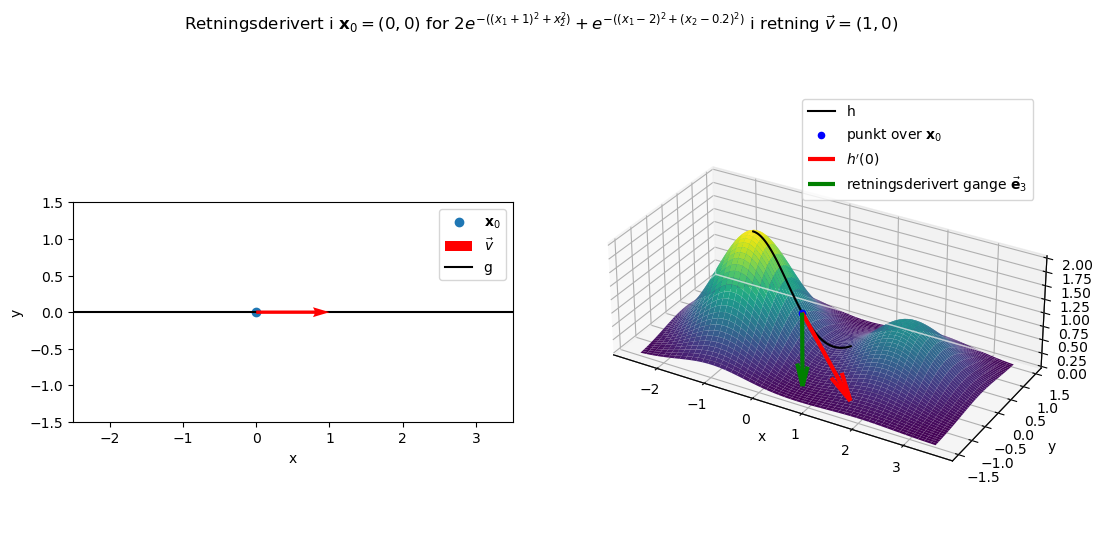

In [3]:
# @title Plotter
# Create a grid of x and y values
x1 = np.linspace(-2.5, 3.5, 300)
x2 = np.linspace(-1.5, 1.5, 300)
x = np.meshgrid(x1, x2)
x0 = np.array([[0], [0]])
t = np.linspace(-1, 1, 100)

x0 = np.array([[0],[0]])
v = np.array([[1],[0]])
g = x0 + v * t[None, :]

# Compute the function values

x3 = f(x)

fig = plt.figure(figsize=1.3*plt.figaspect(0.5))
fig.suptitle(r"Retningsderivert i $\mathbf{x}_0 = (0,0)$ for $2e^{-((x_1 + 1)^2 + x_2^2)} + e^{-((x_1 - 2)^2 + (x_2-0.2)^2)}$ i retning $\vec v = (1,0)$")

# First subplot (left)
ax = fig.add_subplot(1, 2, 1)  # Change to (1, 2, 1)

ax.scatter(*x0, label=r"$\mathbf{x}_0$")
ax.quiver(x0[0], x0[1], v[0], v[1],
          scale=1, scale_units='x',
        color = 'red', alpha = 1, lw = 3, label=r"$\vec v$", zorder=3)
ax.plot(*5*g,zorder=2, color='black', label='g')
# Set labels
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_aspect(1)
ax.set_xlim([-2.5,3.5])
ax.set_ylim([-1.5,1.5])
plt.legend()

ax = fig.add_subplot(1, 2, 2, projection='3d')

ax.plot_surface(x[0], x[1], x3, cmap='viridis', edgecolor='none', alpha=1)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('y')
ax.set_box_aspect([6, 3, 2])

ax2 = kopier_akse(fig, ax)
ax2.plot(g[0], g[1], f(g), color='black', label='h')
ax2.scatter(x0[0], x0[1], f(x0), color='blue', label=r'punkt over $\mathbf{x}_0$')

ax2.quiver(x0[0], x0[1], f(x0), v[0], v[1], numerisk_retningsderivert(f, x0, v),
        color = 'red', alpha = 1, lw = 3, label="$h'(0)$"); # Set labels
ax2.quiver(x0[0], x0[1], f(x0), 0, 0, numerisk_retningsderivert(f, x0, v),
        color = 'green', alpha = 1, lw = 3, label=r"retningsderivert gange $\vec{\mathbf{e}}_3$"); # Set labels
plt.legend();

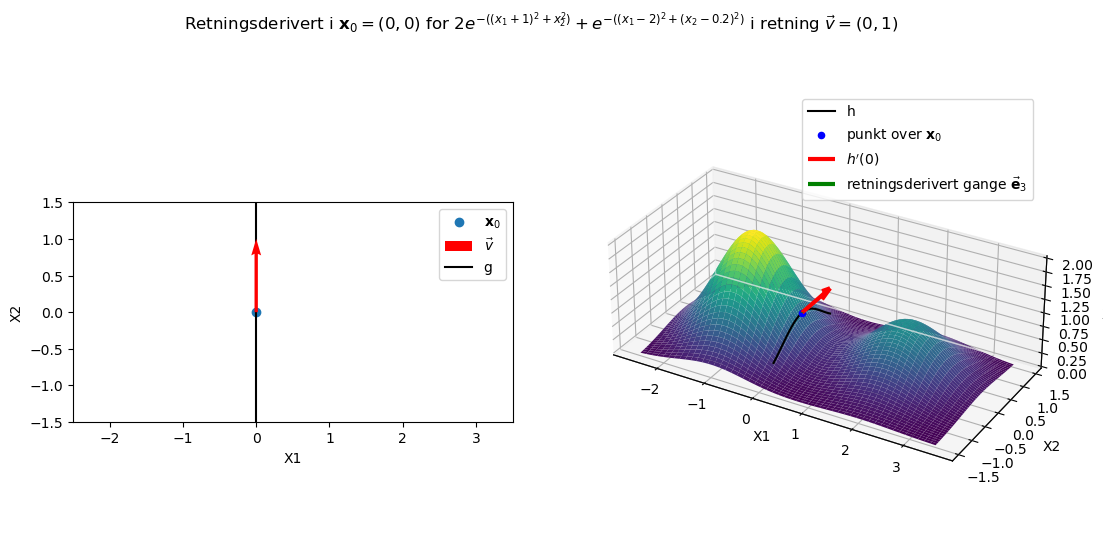

In [4]:
# @title Plotter
# Create a grid of x and y values
x1 = np.linspace(-2.5, 3.5, 300)
x2 = np.linspace(-1.5, 1.5, 300)
x = np.meshgrid(x1, x2)
x0 = np.array([[0], [0]])
t = np.linspace(-1, 1, 100)

x0 = np.array([[0],[0]])
v = np.array([[0],[1]])
g = x0 + v * t[None, :]

# Compute the function values
x3 = f(x)

fig = plt.figure(figsize=1.3*plt.figaspect(0.5))
fig.suptitle(r"Retningsderivert i $\mathbf{x}_0 = (0,0)$ for $2e^{-((x_1 + 1)^2 + x_2^2)} + e^{-((x_1 - 2)^2 + (x_2-0.2)^2)}$ i retning $\vec v = (0,1)$")

# First subplot (left)
ax = fig.add_subplot(1, 2, 1)  # Change to (1, 2, 1)

ax.scatter(*x0, label=r"$\mathbf{x}_0$")
ax.quiver(x0[0], x0[1], v[0], v[1],
          scale=1, scale_units='x',
        color = 'red', alpha = 1, lw = 3, label=r"$\vec v$", zorder=3)
ax.plot(*5*g,zorder=2, color='black', label='g')
# Set labels
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_aspect(1)
ax.set_xlim([-2.5,3.5])
ax.set_ylim([-1.5,1.5])
plt.legend()

# Set up a figure twice as wide as it is tall
# fig = plt.figure(figsize=1.3*plt.figaspect(0.5))

ax = fig.add_subplot(1, 2, 2, projection='3d')

ax.plot_surface(x[0], x[1], x3, cmap='viridis', edgecolor='none', alpha=1)
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('X3')
ax.set_box_aspect([6, 3, 2])

ax2 = kopier_akse(fig, ax)
ax2.plot(g[0], g[1], f(g), color='black', label='h')
ax2.scatter(x0[0], x0[1], f(x0), color='blue', label=r'punkt over $\mathbf{x}_0$')

ax2.quiver(x0[0], x0[1], f(x0), v[0], v[1], numerisk_retningsderivert(f, x0, v),
        color = 'red', alpha = 1, lw = 3, label="$h'(0)$"); # Set labels
ax2.quiver(x0[0], x0[1], f(x0), 0, 0, numerisk_retningsderivert(f, x0, v),
        color = 'green', alpha = 1, lw = 3, label=r"retningsderivert gange $\vec{\mathbf{e}}_3$"); # Set labels
plt.legend();

**Oppgave 1**. Bruk formelen
$$\lim_{\mathbf{t}\to 0} \frac{|f(\mathbf{x}_0+ t\vec{\mathbf{v}}) - f(\mathbf{x}_0) -
  f'(\mathbf{x}_0) \cdot t\vec{\mathbf{v}}|}{|t\vec{\mathbf{v}}|} = 0.$$
til å forklare hvorfor
$D_{\vec{\mathbf{v}}} f(\mathbf{x}_0) = f'(\mathbf{x}_0)\cdot \vec{\mathbf{v}}$.

Husk at enhetsvektoren $\vec{\mathbf{e}}_i$ er en vektor med lengde 1 i
retning $i$-aksen. Det vil si at
$\vec{\mathbf{e}}_i = \begin{bmatrix} 0 \\ \vdots \\ 1 \\ \vdots \\ 0 \end{bmatrix}$,
der 1 står på $i$-te plass.

---
**Definisjon 2**. Den retningsderiverte av $f$ i punktet $\mathbf{x}_0$
i retning $\vec{\mathbf{e}}_i$ kalles den $i$-te partiellderiverte av
$f$ i punktet $\mathbf{x}_0$ og skrives
$$\frac{\partial f}{\partial x_i}(\mathbf{x}_0) = D_{\vec{\mathbf{e}}_i} f(\mathbf{x}_0).$$

Fra oppgave
<a href="#retningsderivertderivert" data-reference-type="ref"
data-reference="retningsderivertderivert">1</a> har vi at
$$\frac{\partial f}{\partial x_i}(\mathbf{x}_0) = f'(\mathbf{x}_0)\cdot \vec{\mathbf{e}}_i.$$
Gitt en radvektor $\vec{\mathbf{v}}= [v_1, \dots, v_n]$ er
$\vec{\mathbf{v}}= [\vec{\mathbf{v}}\cdot \vec{\mathbf{e}}_1, \dots, \vec{\mathbf{v}}\cdot \vec{\mathbf{e}}_n]$.
Derfor er
$$f'(\mathbf{x}_0) = \begin{bmatrix} \frac{\partial f}{\partial x_1}(\mathbf{x}_0) & \dots & \frac{\partial f}{\partial x_n}(\mathbf{x}_0) \end{bmatrix}.$$

For en vektorfunksjon $\mathbf{F}\colon \mathbb{R}^n \to \mathbb{R}^m$
på formen
$$\mathbf{F}(\mathbf{x}) = \begin{bmatrix} F_1(\mathbf{x}) \\ F_2(\mathbf{x}) \\ \vdots \\ F_m(\mathbf{x}) \end{bmatrix},$$
har vi
$$\mathbf{F}'(\mathbf{x}_0) = \begin{bmatrix} F'_1(\mathbf{x}_0) \\ F'_2(\mathbf{x}_0) \\ \vdots \\ F'_m(\mathbf{x}_0) \end{bmatrix}
=
\begin{bmatrix}
  \frac{\partial F_1}{\partial x_1}
  & \dots &
  \frac{\partial F_1}{\partial x_n}
  \\
  \frac{\partial F_2}{\partial x_1}
  & \dots &
  \frac{\partial F_2}{\partial x_n}
  \\
  \vdots &&  \vdots \\
  \frac{\partial F_m}{\partial x_1}
         & \dots&
  \frac{\partial F_m}{\partial x_n}
  \end{bmatrix}.$$

**Oppgave 2**. Per definisjon er den retningsderiverte av en
vektorfunksjon den deriverte til en funksjon av en variabel. Beskriv en
funksjon $h \colon \mathbb{R}\to \mathbb{R}$ slik at
$\frac{\partial \mathbf{F}}{\partial x_i}(\mathbf{x}_0) = h'(0)$.

**Eksempel 2**
I eksempel 1 har vi faktisk tegnet de to partielle deriverte i punktet $\mathbf{x}_0$.

**Definisjon 3**. *Gradienten* til en vektorfunksjon
$f \colon \mathbb{R}^n \to \mathbb{R}$ i et punkt
$\mathbf{x}_0 \in \mathbb{R}^n$ er punktet
$$\nabla f(\mathbf{x}_0) = \begin{bmatrix}\frac{\partial f}{\partial x_1}(\mathbf{x}_0) \\ \vdots \\ \frac{\partial f}{\partial x_n}(\mathbf{x}_0)\end{bmatrix} \in  \mathbb{R}^n$$

*Bemerkning*. Gradienten $\nabla f(\mathbf{x}_0)$ er en
kolonnevektor, og $f'(\mathbf{x}_0)$ er radvektoren som fås ved å legge
denne kolonnevektoren ned som vi gjorde da vi definerte
matrisemultiplikasjon.

**Eksempel 6**

Vi tegner noen gradienter til funksjonen
$f \colon \mathbb{R}^2 \to \mathbb{R}$ gitt ved
$$f(\begin{bmatrix} x_1 \\ x_2 \end{bmatrix}) =
  2e^{-((x_1 + 1)^2 + x_2^2)}
  +
  e^{-((x_1 - 2)^2 + (x_2 - 0.2)^2)}
  .$$

In [5]:
# @title Kode for gradient
def numerisk_retningsderivert(funksjon, punkt, v, epsilon=1e-4):
    q = punkt + epsilon * v
    return (funksjon(q) - funksjon(punkt))/epsilon

def numerisk_gradient(funksjon, punkt, epsilon=1e-4):
    gradient = np.zeros_like(punkt)
    v = np.zeros_like(punkt)
    for idx in range(punkt.shape[0]):
        v[idx] = 1
        gradient[idx] = numerisk_retningsderivert(funksjon, punkt, v, epsilon)
        v[idx] = 0
    return gradient

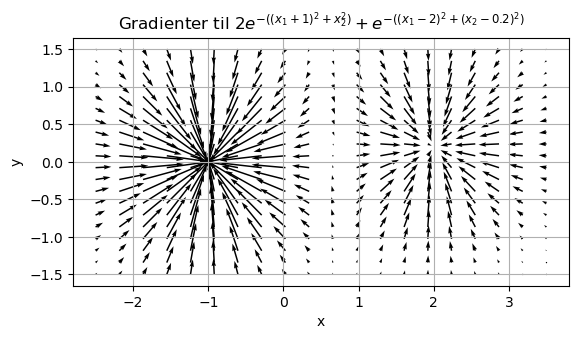

In [6]:
# @title Plotter
n_grid = 20


# Definerer x- og y-verdiene

x1 = np.linspace(-2.5, 3.5, n_grid)
x2 = np.linspace(-1.5, 1.5, n_grid)

# Finner retning av piler
X, Y = np.meshgrid(x1, x2)
dX, dY = numerisk_gradient(f, np.vstack([X.ravel(),Y.ravel()]))
dX = dX.reshape(X.shape)
dY = dY.reshape(Y.shape)
#dX = np.sign(dX)*np.abs(dX)**0.3
#dY = np.sign(dY)*np.abs(dY)**0.3

plt.quiver(X, Y, dX, dY, scale=3, scale_units='x', color='black', angles='xy')
#plt.plot(t, x_2(t), label='x(t) = 2e^t')
#plt.ylim((0, 5))
plt.grid()
# plt.plot(z[0], z[1])
plt.xlabel('x')
plt.ylabel('y')
ax = plt.gca()
ax.set_aspect(1)
#plt.legend(loc='upper left')
plt.title(r"Gradienter til $2e^{-((x_1 + 1)^2 + x_2^2)} + e^{-((x_1 - 2)^2 + (x_2-0.2)^2)}$");

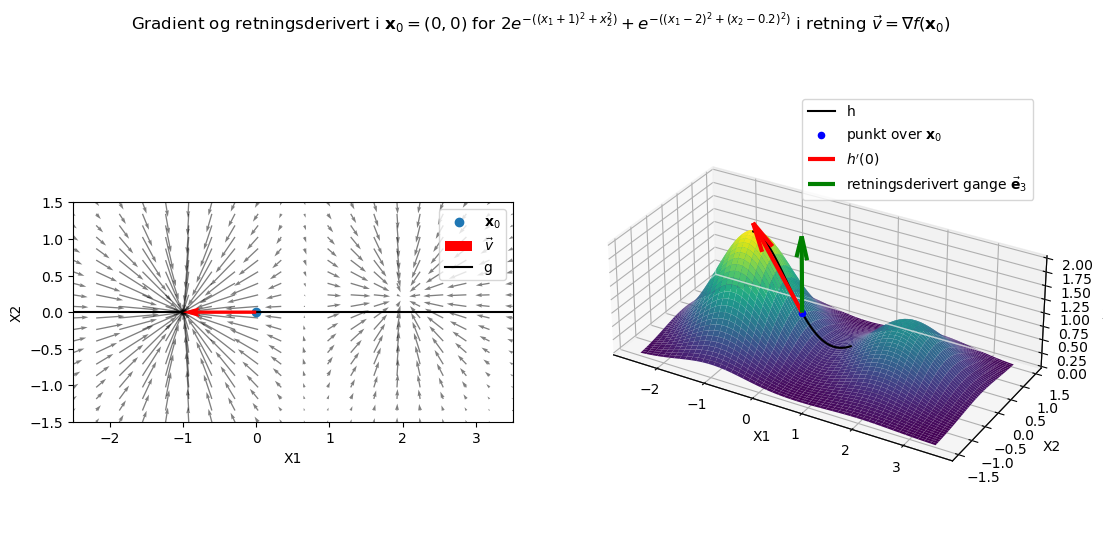

In [7]:
# @title Plotter
# Create a grid of x and y values
x1 = np.linspace(-2.5, 3.5, 300)
x2 = np.linspace(-1.5, 1.5, 300)
xx = np.meshgrid(x1, x2)
x0 = np.array([[0], [0]])
t = np.linspace(-1, 1, 100)

x0 = np.array([[0],[0]])
v = numerisk_gradient(f, x0)
g = x0 + v * t[None, :]

# Compute the function values
x3 = f(xx)

fig = plt.figure(figsize=1.3*plt.figaspect(0.5))
fig.suptitle(r"Gradient og retningsderivert i $\mathbf{x}_0 = (0,0)$ for $2e^{-((x_1 + 1)^2 + x_2^2)} + e^{-((x_1 - 2)^2 + (x_2 - 0.2)^2)}$ i retning $\vec v = \nabla f(\mathbf{x}_0)$")

# First subplot (left)
ax = fig.add_subplot(1, 2, 1)  # Change to (1, 2, 1)

n_grid = 20


# Definerer x- og y-verdiene

x = np.linspace(-2.5, 3.5, n_grid)
y = np.linspace(-1.5, 1.5, n_grid)

# Finner retning av piler
X, Y = np.meshgrid(x, y)
dX, dY = numerisk_gradient(f, np.vstack([X.ravel(),Y.ravel()]))
dX = dX.reshape(X.shape)
dY = dY.reshape(Y.shape)
#dX = np.sign(dX)*np.abs(dX)**0.3
#dY = np.sign(dY)*np.abs(dY)**0.3

ax.quiver(X, Y, dX, dY, scale=3, scale_units='x', color='black', angles='xy', alpha=0.5)
#plt.plot(t, x_2(t), label='x(t) = 2e^t')
#plt.ylim((0, 5))

ax.scatter(*x0, label=r"$\mathbf{x}_0$")
ax.quiver(x0[0], x0[1], v[0], v[1],
          scale=1, scale_units='x',
        color = 'red', alpha = 1, lw = 3, label=r"$\vec v$", zorder=3)
ax.plot(*5*g,zorder=2, color='black', label='g')
# Set labels
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_xlim([-2.5,3.5])
ax.set_ylim([-1.5,1.5])
ax.set_aspect(1)
plt.legend()

ax = fig.add_subplot(1, 2, 2, projection='3d')

ax.plot_surface(xx[0], xx[1], x3, cmap='viridis', edgecolor='none', alpha=1)
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('X3')
ax.set_box_aspect([6, 3, 2])

ax2 = kopier_akse(fig, ax)
ax2.plot(g[0], g[1], f(g), color='black', label='h')
ax2.scatter(x0[0], x0[1], f(x0), color='blue', label=r'punkt over $\mathbf{x}_0$')

ax2.quiver(x0[0], x0[1], f(x0), v[0], v[1], numerisk_retningsderivert(f, x0, v),
        color = 'red', alpha = 1, lw = 3, label="$h'(0)$"); # Set labels
ax2.quiver(x0[0], x0[1], f(x0), 0, 0, numerisk_retningsderivert(f, x0, v),
        color = 'green', alpha = 1, lw = 3, label=r"retningsderivert gange $\vec{\mathbf{e}}_3$"); # Set labels
plt.legend();

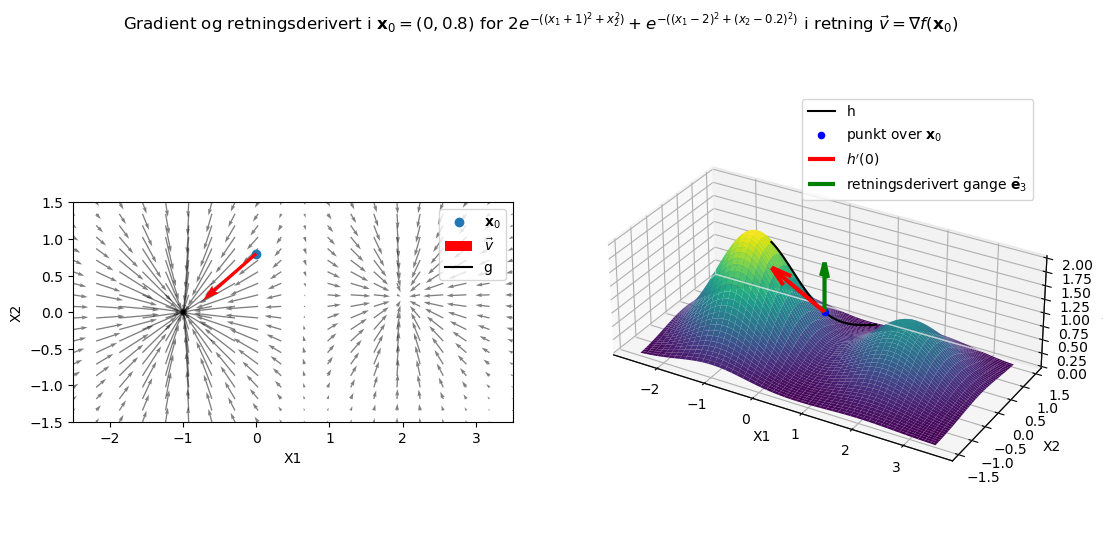

In [8]:
# @title Plotter
# Create a grid of x and y values
x1 = np.linspace(-2.5, 3.5, 300)
x2 = np.linspace(-1.5, 1.5, 300)
xx = np.meshgrid(x1, x2)
x0 = np.array([[0],[.8]])
t = np.linspace(-1, 1, 100)

v = numerisk_gradient(f, x0)
g = x0 + v * t[None, :]

# Compute the function values
x3 = f(xx)

fig = plt.figure(figsize=1.3*plt.figaspect(0.5))
fig.suptitle(r"Gradient og retningsderivert i $\mathbf{x}_0 = (0,0.8)$ for $2e^{-((x_1 + 1)^2 + x_2^2)} + e^{-((x_1 - 2)^2 + (x_2-0.2)^2)}$ i retning $\vec v = \nabla f(\mathbf{x}_0)$")

# First subplot (left)
ax = fig.add_subplot(1, 2, 1)  # Change to (1, 2, 1)

n_grid = 20


# Definerer x- og y-verdiene

x = np.linspace(-2.5, 3.5, n_grid)
y = np.linspace(-1.5, 1.5, n_grid)

# Finner retning av piler
X, Y = np.meshgrid(x, y)
dX, dY = numerisk_gradient(f, np.vstack([X.ravel(),Y.ravel()]))
dX = dX.reshape(X.shape)
dY = dY.reshape(Y.shape)
#dX = np.sign(dX)*np.abs(dX)**0.3
#dY = np.sign(dY)*np.abs(dY)**0.3

ax.quiver(X, Y, dX, dY, scale=3, scale_units='x', color='black', angles='xy', alpha=0.5)
ax.scatter(*x0, label=r"$\mathbf{x}_0$")
ax.quiver(x0[0], x0[1], v[0], v[1],
          scale=1, scale_units='x',
        color = 'red', alpha = 1, lw = 3, label=r"$\vec v$", zorder=3)
ax.plot(*5*g,zorder=2, color='black', label='g')
# Set labels
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_xlim([-2.5,3.5])
ax.set_ylim([-1.5,1.5])
ax.set_aspect(1)
plt.legend()

ax = fig.add_subplot(1, 2, 2, projection='3d')

ax.plot_surface(xx[0], xx[1], x3, cmap='viridis', edgecolor='none', alpha=1)
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('X3')
ax.set_box_aspect([6, 3, 2])

ax2 = kopier_akse(fig, ax)
ax2.plot(g[0], g[1], f(g), color='black', label='h')
ax2.scatter(x0[0], x0[1], f(x0), color='blue', label=r'punkt over $\mathbf{x}_0$')

ax2.quiver(x0[0], x0[1], f(x0), v[0], v[1], numerisk_retningsderivert(f, x0, v),
        color = 'red', alpha = 1, lw = 3, label="$h'(0)$"); # Set labels
ax2.quiver(x0[0], x0[1], f(x0), 0, 0, numerisk_retningsderivert(f, x0, v),
        color = 'green', alpha = 1, lw = 3, label=r"retningsderivert gange $\vec{\mathbf{e}}_3$"); # Set labels
plt.legend();

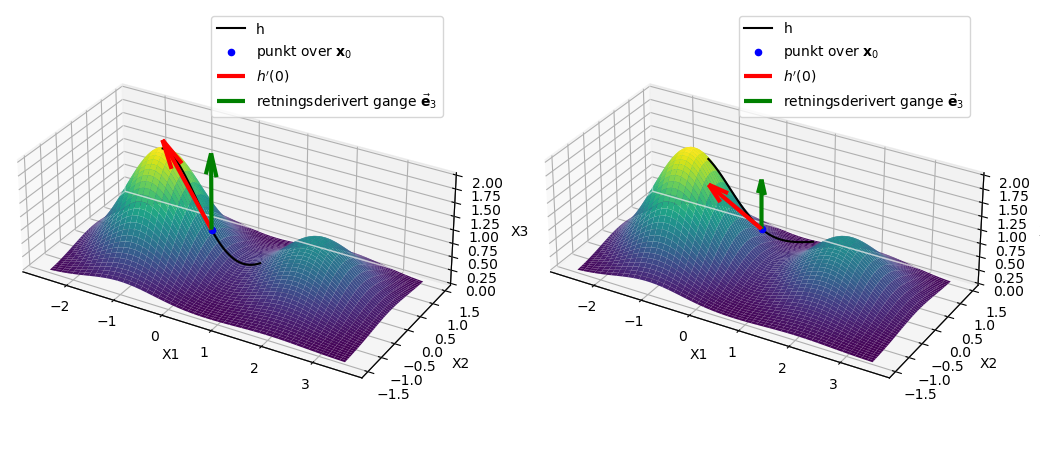

In [9]:
# @title Plotter
# Create a grid of x and y values
x1 = np.linspace(-2.5, 3.5, 300)
x2 = np.linspace(-1.5, 1.5, 300)
x = np.meshgrid(x1, x2)
t = np.linspace(-1, 1, 100)
x3 = f(x) # Compute the function values

# @title Default title text
x0 = np.array([[0],[0]])
v = numerisk_gradient(f, x0)
g = x0 + v * t[None, :]

# Set up a figure twice as wide as it is tall
fig = plt.figure(figsize=1.3*plt.figaspect(0.5))

# First subplot (left)
ax = fig.add_subplot(1, 2, 1, projection='3d')

ax.plot_surface(x[0], x[1], x3, cmap='viridis', edgecolor='none', alpha=1)
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('X3')
ax.set_box_aspect([6, 3, 2])

ax2 = kopier_akse(fig, ax)
# ax2 = fig.add_subplot(1, 2, 1, projection='3d', label="quiver_layer1")
ax2.plot(g[0], g[1], f(g), color='black', label='h')
ax2.scatter(x0[0], x0[1], f(x0), color='blue', label=r'punkt over $\mathbf{x}_0$')

ax2.quiver(x0[0], x0[1], f(x0), v[0], v[1], numerisk_retningsderivert(f, x0, v),
        color = 'red', alpha = 1, lw = 3, label="$h'(0)$") # Set labels
ax2.quiver(x0[0], x0[1], f(x0), 0, 0, numerisk_retningsderivert(f, x0, v),
        color = 'green', alpha = 1, lw = 3, label=r"retningsderivert gange $\vec{\mathbf{e}}_3$"); # Set labels
plt.legend()

x0 = np.array([[0],[.8]])
v = numerisk_gradient(f, x0)
g = x0 + v * t[None, :]

ax = fig.add_subplot(1, 2, 2, projection='3d')

ax.plot_surface(x[0], x[1], x3, cmap='viridis', edgecolor='none', alpha=1)
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('X3')
ax.set_box_aspect([6, 3, 2])

ax2 = kopier_akse(fig, ax)
# ax2 = fig.add_subplot(1, 2, 2, projection='3d', label="quiver_layer1")
ax2.plot(g[0], g[1], f(g), color='black', label='h')
ax2.scatter(x0[0], x0[1], f(x0), color='blue', label=r'punkt over $\mathbf{x}_0$')

ax2.quiver(x0[0], x0[1], f(x0), v[0], v[1], numerisk_retningsderivert(f, x0, v),
        color = 'red', alpha = 1, lw = 3, label="$h'(0)$"); # Set label
ax2.quiver(x0[0], x0[1], f(x0), 0, 0, numerisk_retningsderivert(f, x0, v),
        color = 'green', alpha = 1, lw = 3, label=r"retningsderivert gange $\vec{\mathbf{e}}_3$"); # Set labels
plt.legend();

Teoremet under sammenfatter utsagent i Oppgave
1 og sammenhengen mellom
prikkprodukt og vinkler mellom vektorer. Det gir en ny måte å se på
gradienten.

**Teorem**. *Hvis $f\colon \mathbb{R}^n \to \mathbb{R}$ er en
skalarfunksjon og $\mathbf{x}_0$ er et punkt slik at $f'(\mathbf{x}_0)$
er definert, så er
$$D_{\vec{\mathbf{v}}} f(\mathbf{x}_0) = f'(\mathbf{x}_0) \cdot \vec{\mathbf{v}}= \nabla f(\mathbf{x}_0) \cdot
  \vec{\mathbf{v}} = |\nabla f(\mathbf{x}_0)| \cos \theta,$$ for alle
vektorer $\vec{\mathbf{v}}$ med lengde $1$, der $\theta$ er vinkelen
mellom $\vec{\mathbf{v}}$ og $\nabla f(\mathbf{x}_0)$. Derfor $f$ vokser raskest
i retningen $\nabla f(\mathbf{x}_0)$ ut ifra punktet
$\mathbf{x}_0$.*

**Oppgave 3**. Forklar hvorfor funksjonen $f$ avtar raskest i retning
$-\nabla f(\mathbf{x}_0)$.